In [15]:
import numpy as np 
import matplotlib.pyplot as plt 
from astropy.io import fits
import grisutils as gu

In [47]:
examplepath = '/dat/schliche/gris_CHole/20250620/level1/ARM1/20Jun25ARM1.009cc'

In [48]:
stokes = gu.readmaps(examplepath)

0


In [49]:
stokes = np.asarray(stokes)

In [50]:
stokes.shape

(4, 120, 431, 1010)

In [22]:
stokes = np.transpose(stokes, (2,1,0,3))

In [24]:
meanspec = np.mean(stokes, axis=(0,1))
meanspec.shape

(4, 1010)

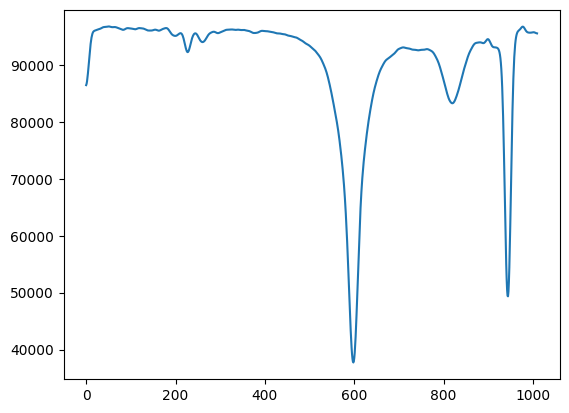

In [25]:
plt.plot(meanspec[0])

In [26]:
l_c_l = 300
l_c_r = 350

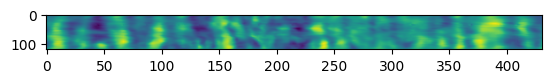

In [32]:
plt.imshow(np.mean(stokes[:,:,0,l_c_l:l_c_r], axis=2).T, aspect='0.25')

In [57]:
# Now make a list of all the coronal hole observations and loop through them to make a big array of all the spectra:

ch_extensions = [2,3,4,6,7,8]
qs_extensions = [9, 11, 12, 13, 14, 15] # Not exactly the same but can be compared, hopefully.

In [58]:
ch_spectra = []
qs_spectra = []

for ext in ch_extensions:
    path = f'/dat/schliche/gris_CHole/20250620/level1/ARM1/20Jun25ARM1.00{ext}cc'
    stokes = gu.readmaps(path)
    stokes = np.asarray(stokes)
    stokes = np.transpose(stokes, (2,1,0,3))
    meanspec = np.mean(stokes, axis=(0,1))
    ch_spectra.append(meanspec)

0
0
0
0
0
0


In [59]:
ch_spectra = np.asarray(ch_spectra)
ch_spectra.shape

(6, 4, 1010)

In [61]:
qs_spectra = []    
for ext in qs_extensions:
    if (ext < 10):
        path = f'/dat/schliche/gris_CHole/20250620/level1/ARM1/20Jun25ARM1.00{ext}cc'
    else:
        path = f'/dat/schliche/gris_CHole/20250620/level1/ARM1/20Jun25ARM1.0{ext}cc'
    stokes = gu.readmaps(path)
    stokes = np.asarray(stokes)
    stokes = np.transpose(stokes, (2,1,0,3))
    meanspec = np.mean(stokes, axis=(0,1))
    qs_spectra.append(meanspec)

0
0
0
0
0
0


In [62]:
qs_spectra = np.asarray(qs_spectra)
qs_spectra.shape
qs_spectra = qs_spectra[::-1,:,:]

(0.88, 1.02)

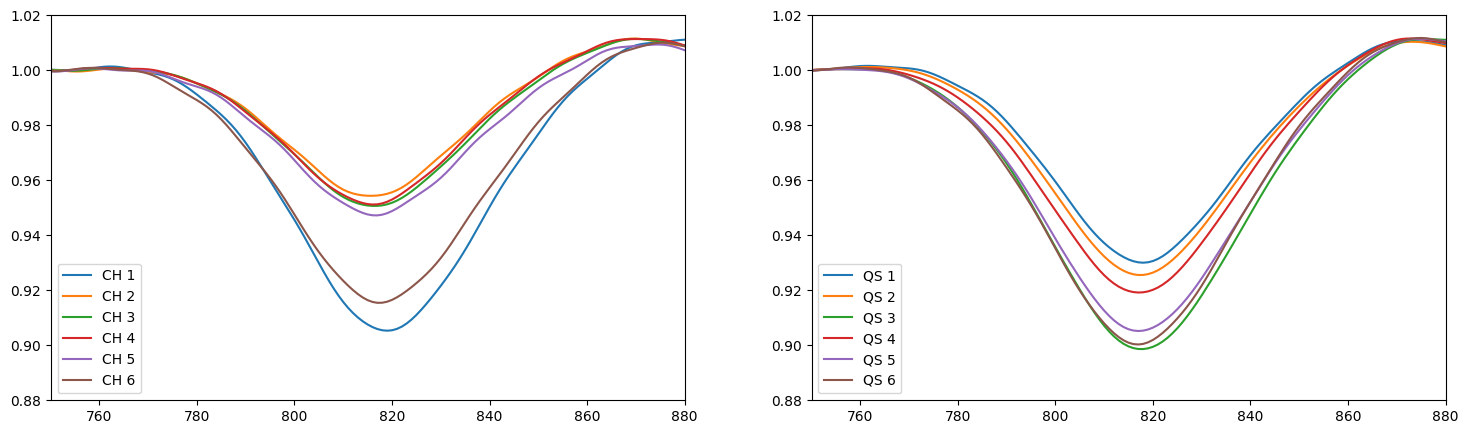

In [72]:
l_c_l = 745
l_c_r = 755

plt.figure(figsize=(18,5))
plt.subplot(121)
for i in range(0,6):
    plt.plot(ch_spectra[i,0]/np.mean(ch_spectra[i,0,l_c_l:l_c_r]), label=f'CH {i+1}')
plt.legend()
plt.xlim(750,880)
plt.ylim(0.88,1.02)

plt.subplot(122)
for i in range(0,6):
    plt.plot(qs_spectra[i,0]/np.mean(qs_spectra[i,0,l_c_l:l_c_r]), label=f'QS {i+1}')
plt.legend()

plt.xlim(750,880)
plt.ylim(0.88,1.02)

In [75]:
stokes_qs_1 = gu.readmaps('/dat/schliche/gris_CHole/20250620/level1/ARM1/20Jun25ARM1.015cc')
stokes_qs_3 = gu.readmaps('/dat/schliche/gris_CHole/20250620/level1/ARM1/20Jun25ARM1.013cc')


0
0


In [77]:
stokes_qs_1 = np.asarray(stokes_qs_1)
stokes_qs_1 = stokes_qs_1.transpose((2,1,0,3))

In [78]:
stokes_qs_3 = np.asarray(stokes_qs_3)
stokes_qs_3 = stokes_qs_3.transpose((2,1,0,3))

In [79]:
stokes_qs_1.shape

(431, 120, 4, 1010)

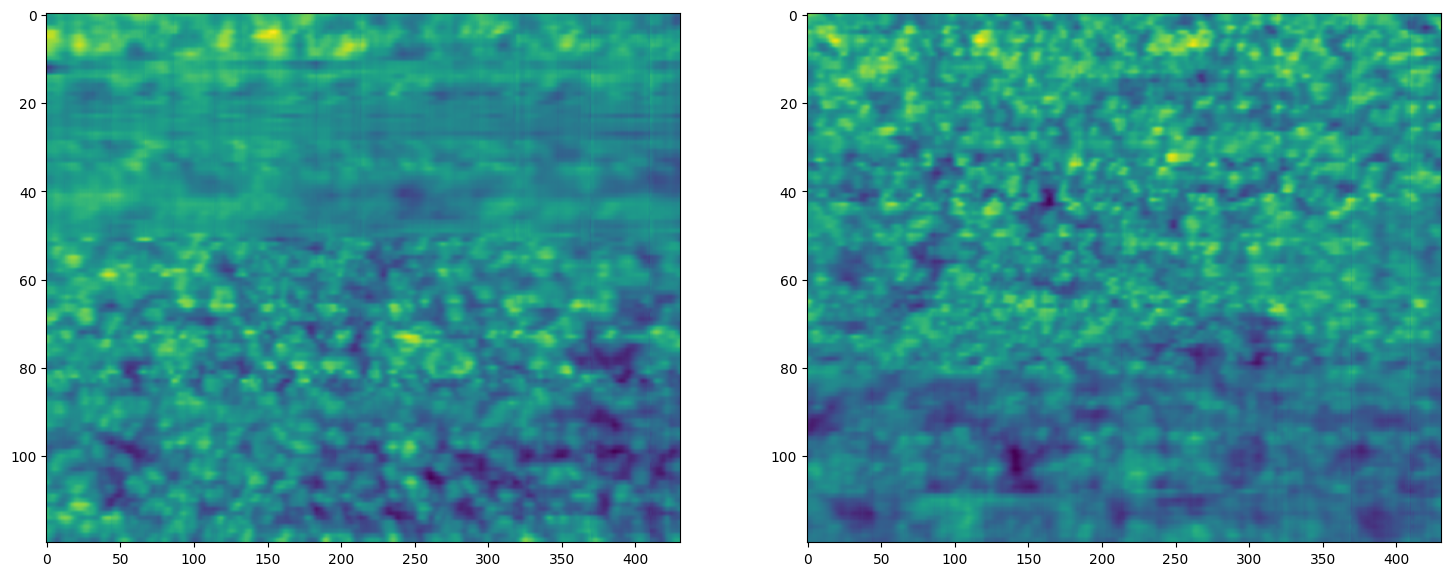

In [84]:
# Now do the maps:
plt.figure(figsize=(18,7))
plt.subplot(121)
plt.imshow(np.mean(stokes_qs_1[:,:,0,l_c_l:l_c_r], axis=2).T, aspect='3.0')
plt.subplot(122)
plt.imshow(np.mean(stokes_qs_3[:,:,0,l_c_l:l_c_r], axis=2).T, aspect='3.0')    

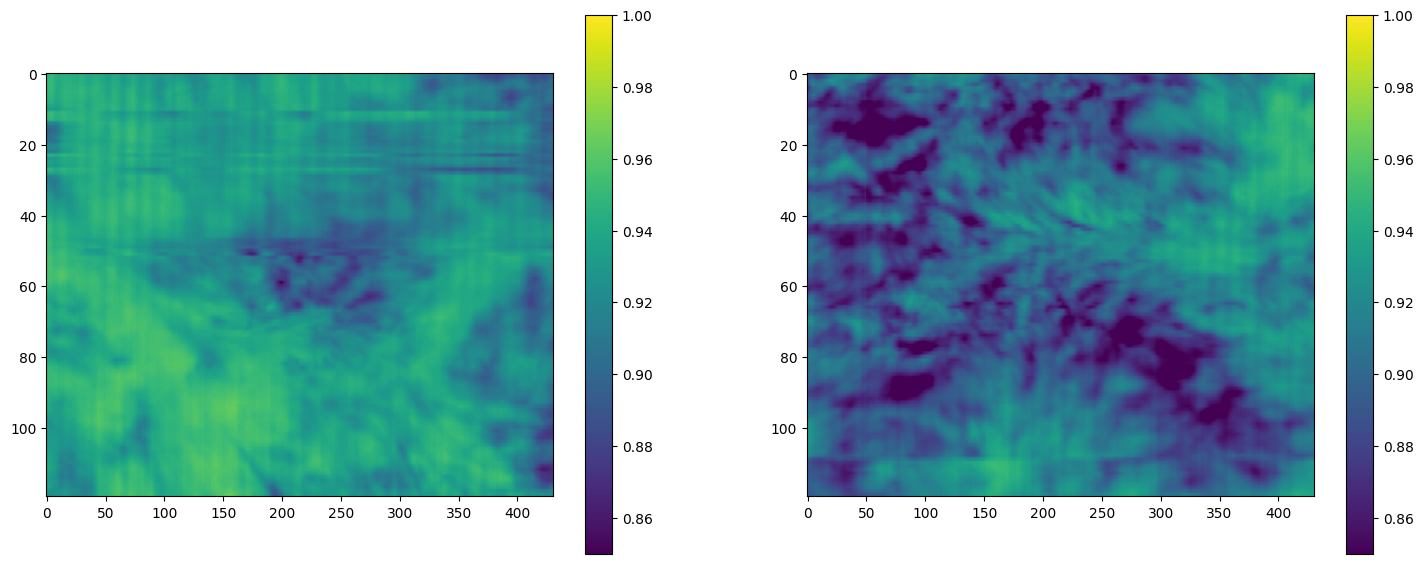

In [90]:
# And the same but with the maps of He 10830 line depth

plt.figure(figsize=(18,7))
plt.subplot(121)
plt.imshow(np.mean(stokes_qs_1[:,:,0,816:820],axis=2).T / np.mean(stokes_qs_1[:,:,0,l_c_l:l_c_r], axis=2).T, aspect='3.0', vmin=0.85, vmax=1.0)
plt.colorbar()
plt.subplot(122)
plt.imshow(np.mean(stokes_qs_3[:,:,0,816:820],axis=2).T / np.mean(stokes_qs_3[:,:,0,l_c_l:l_c_r], axis=2).T, aspect='3.0', vmin=0.85, vmax=1.0) 
plt.colorbar()
